In [3]:
from finagg.fred.api import CategorySeries, SeriesObservations,SeriesCategories,Tags
import pandas as pd
so = SeriesObservations()
sc = SeriesCategories()
ret= []

def get_series(eventid):
    metadata = sc.get(eventid)
    eclass = metadata.iloc[-1]['name']
    df = so.get(eventid )[['series_id', 'value', 'date']]
    df.columns= ['event', 'actual', 'datetime']
    df['eclass'] = eclass
    df['datetime'] = pd.to_datetime(df.datetime)
    return df



In [29]:
jp10yr = get_series('IRLTLT01JPM156N')
us10yr=  get_series('DGS10')
usdjpy = get_series('DEXJPUS')

jp10yr_m = jp10yr.set_index('datetime').resample('ME').last()['actual']
us10yr_m = us10yr.set_index('datetime').resample('ME').last()['actual']
usdjpy_m = usdjpy.set_index('datetime').resample('ME').last()['actual']





In [50]:
jp_usd_spread = us10yr_m -jp10yr_m

dfall= pd.concat([jp_usd_spread , usdjpy_m], axis=1).dropna()
dfall.columns = ['10yr_spread', 'usdjpy']

In [85]:
import matplotlib.pyplot as plt
def plot(year, year2=2025):
    plt.figure(figsize= (10, 5))
    tmp = dfall[(dfall.index.year >= year) & (dfall.index.year <= year2)]

    corr = tmp['usdjpy'].corr(tmp['10yr_spread'])
    ax = tmp['usdjpy'].plot()
    tmp['10yr_spread'].plot(secondary_y=True, ax=ax, label='10yr_spread', linestyle='--')
    ax.set_title("Year: %d-%d Correlation: %.4f" % (year, year2, corr))
    
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax.right_ax.get_legend_handles_labels()

    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", bbox_to_anchor=(1.02,1))
    
    

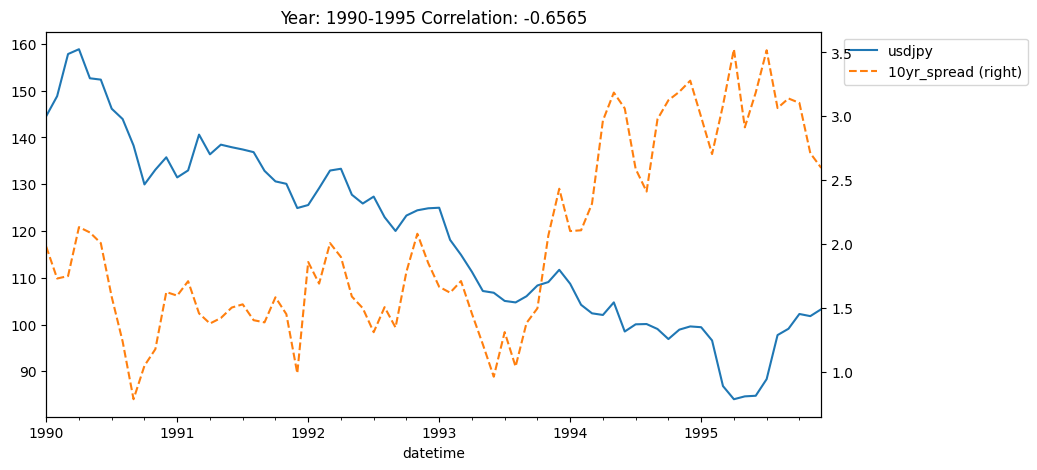

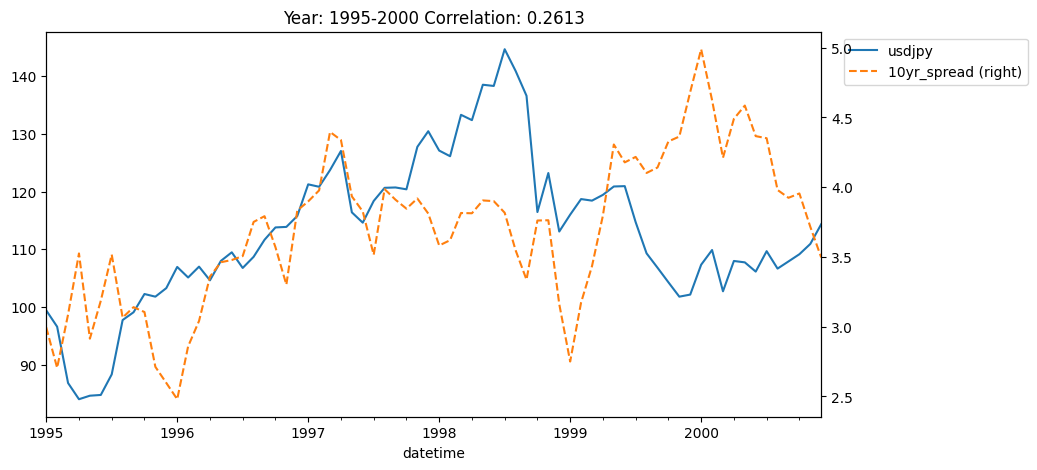

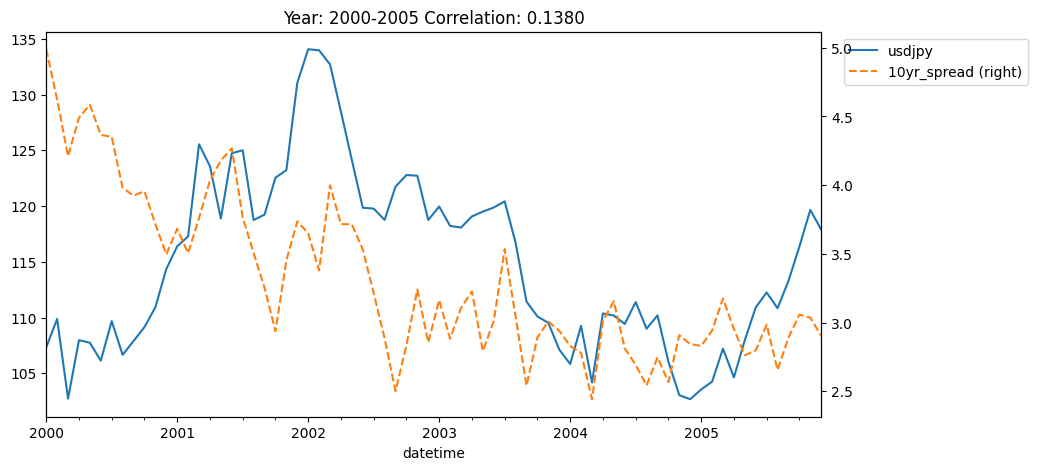

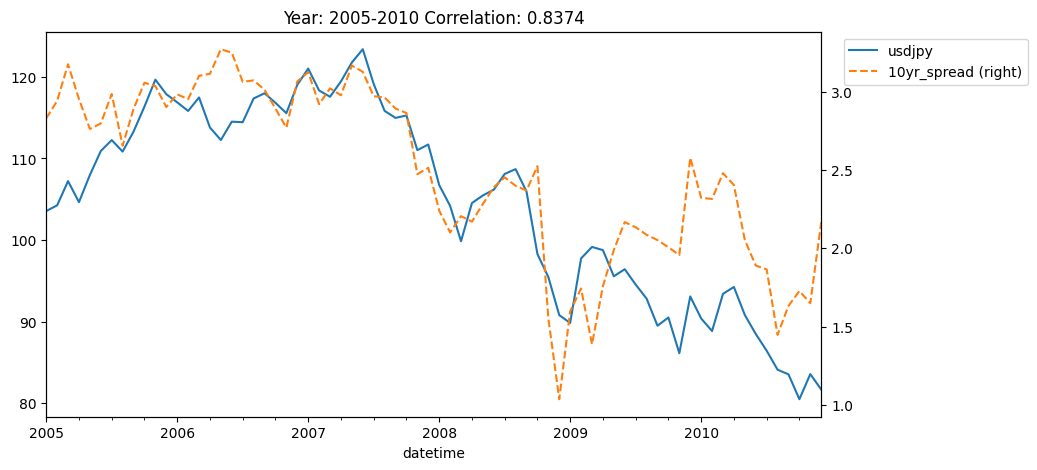

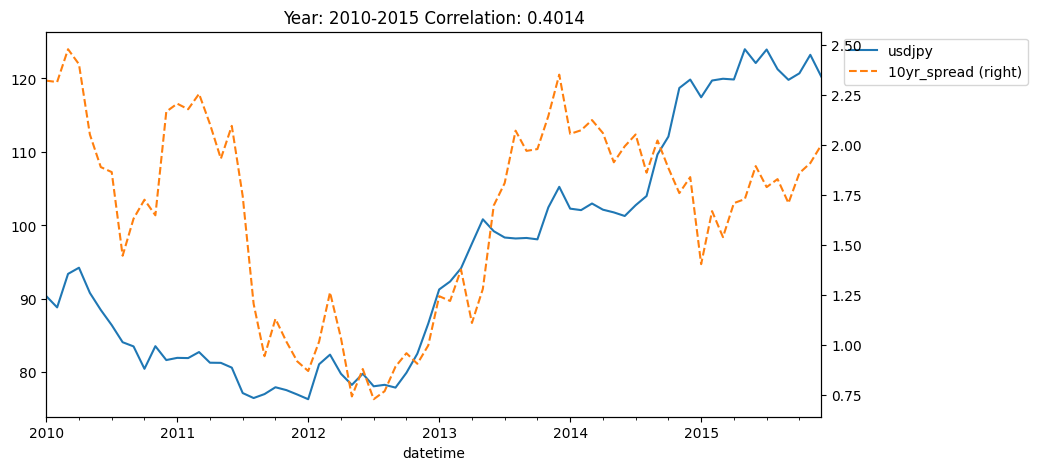

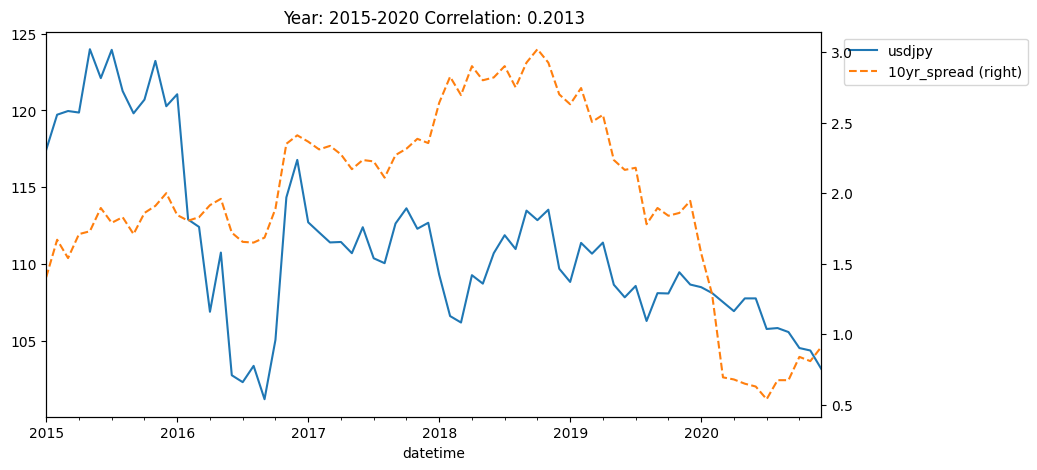

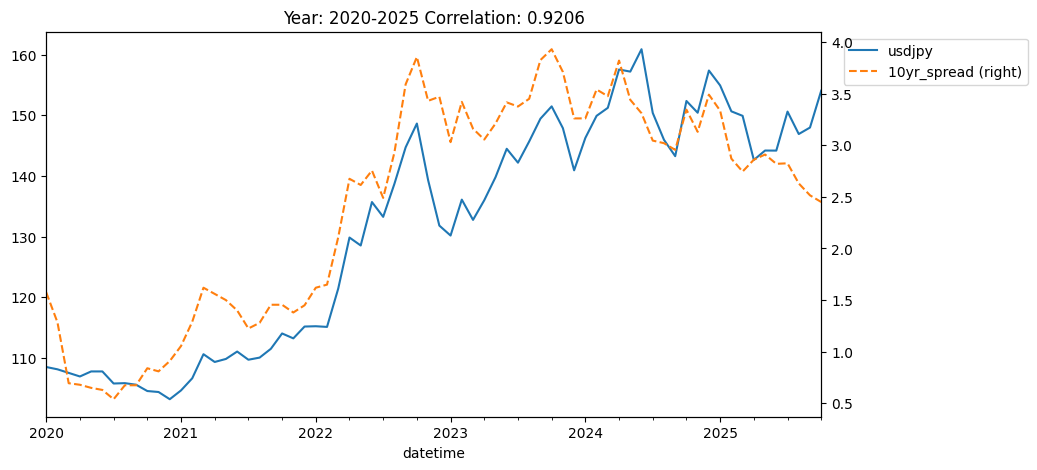

In [87]:
for i in range(1990 , 2025, 5):
    plot(i, i+5)